In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Question 2 — Gamma on $L^*$ in $L^*a^*b^*$ (`highlights_and_shadows.jpg`)

**(a)** Apply gamma **only to the L channel** in OpenCV Lab (`BGR` → `LAB` → edit `L` → `LAB2BGR`). Normalize $L$ to $[0,1]$, then $s = r^\gamma$.

**Stated $\gamma$:** `GAMMA = 0.5` (in code below). With $\gamma < 1$, darker $L$ is lifted more; $a^*$ and $b^*$ are unchanged.

**(b)** Histograms: $L$ before/after, and grayscale histograms of the full original vs corrected images.

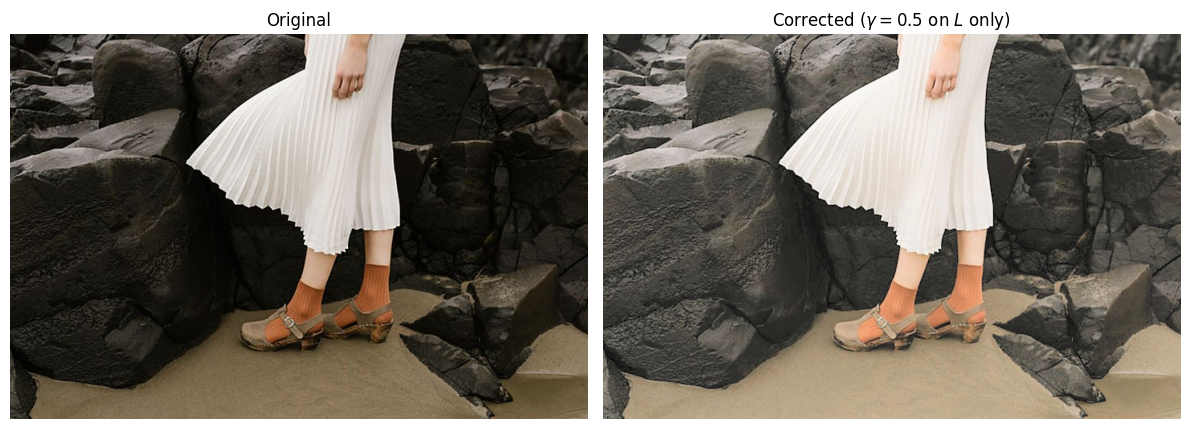

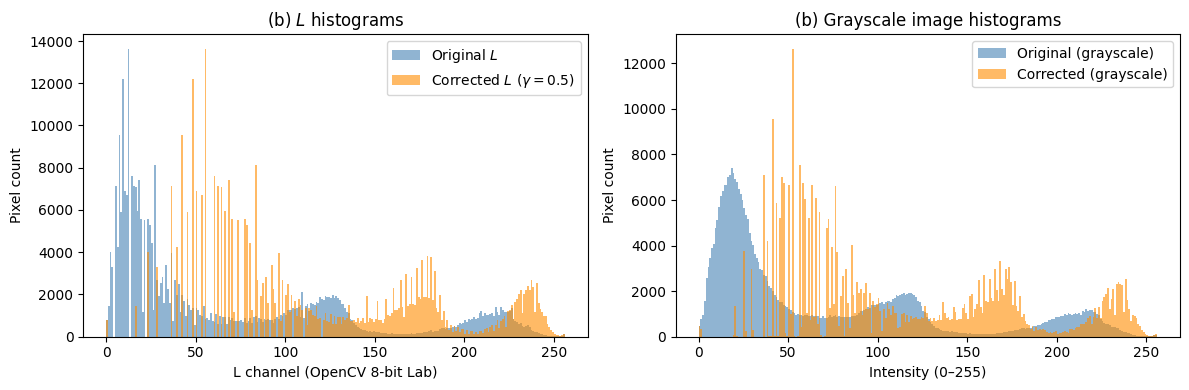

Gamma applied to L only: gamma = 0.5


In [3]:
GAMMA = 0.5  # part (a): state this value in your report

path = "images/highlights_and_shadows.jpg"
bgr = cv2.imread(path)
if bgr is None:
    raise FileNotFoundError(path)

lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab)

L_f = L.astype(np.float64) / 255.0
L_corr_f = np.clip(L_f ** GAMMA, 0.0, 1.0)
L_corr = np.clip(np.round(L_corr_f * 255.0), 0, 255).astype(np.uint8)

lab_corr = cv2.merge([L_corr, a, b])
bgr_corr = cv2.cvtColor(lab_corr, cv2.COLOR_LAB2BGR)

rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
rgb_corr = cv2.cvtColor(bgr_corr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(rgb)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(rgb_corr)
axes[1].set_title(rf"Corrected ($\gamma={GAMMA}$ on $L$ only)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
gray_corr = cv2.cvtColor(bgr_corr, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(L.ravel(), bins=256, range=(0, 256), color="steelblue", alpha=0.6, label="Original $L$")
axes[0].hist(L_corr.ravel(), bins=256, range=(0, 256), color="darkorange", alpha=0.6, label=rf"Corrected $L$ ($\gamma={GAMMA}$)")
axes[0].set_xlabel("L channel (OpenCV 8-bit Lab)")
axes[0].set_ylabel("Pixel count")
axes[0].set_title("(b) $L$ histograms")
axes[0].legend()

axes[1].hist(gray.ravel(), bins=256, range=(0, 256), color="steelblue", alpha=0.6, label="Original (grayscale)")
axes[1].hist(gray_corr.ravel(), bins=256, range=(0, 256), color="darkorange", alpha=0.6, label="Corrected (grayscale)")
axes[1].set_xlabel("Intensity (0–255)")
axes[1].set_ylabel("Pixel count")
axes[1].set_title("(b) Grayscale image histograms")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Gamma applied to L only: gamma = {GAMMA}")